In [1]:
import mne
import numpy as np
import os

mne.set_log_level('WARNING')  # suppress verbose output

# Base paths
PHYSIONET_BASE = "../data/physionet/physionet.org/files/eegmmidb/1.0.0"
BCI_BASE = "../data/bci_iv_2a/BCICIV_2a_gdf"

In [2]:
# Read S001 Run 04 (left/right hand imagery)
physio_path = os.path.join(PHYSIONET_BASE, "S001", "S001R04.edf")
raw = mne.io.read_raw_edf(physio_path, preload=True)

print("=== PhysioNet S001 Run 04 ===")
print(f"Sampling rate:    {raw.info['sfreq']} Hz")
print(f"Number of channels: {len(raw.ch_names)}")
print(f"Channel names:    {raw.ch_names[:5]}... (first 5)")
print(f"Duration:         {raw.times[-1]:.1f} seconds")
print(f"Total samples:    {len(raw.times)}")

=== PhysioNet S001 Run 04 ===
Sampling rate:    160.0 Hz
Number of channels: 64
Channel names:    ['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.']... (first 5)
Duration:         125.0 seconds
Total samples:    20000


In [3]:
# Check event labels
events, event_id = mne.events_from_annotations(raw)

print("=== Annotations ===")
print(f"Event types found: {event_id}")
print(f"Total events:      {len(events)}")
print(f"\nFirst 10 events:")
for e in events[:10]:
    print(f"  Sample {e[0]:6d} → label {e[2]}")

=== Annotations ===
Event types found: {'T0': 1, 'T1': 2, 'T2': 3}
Total events:      30

First 10 events:
  Sample      0 → label 1
  Sample    672 → label 3
  Sample   1328 → label 1
  Sample   2000 → label 2
  Sample   2656 → label 1
  Sample   3328 → label 2
  Sample   3984 → label 1
  Sample   4656 → label 3
  Sample   5312 → label 1
  Sample   5984 → label 3


In [4]:
# Read A01T.gdf (subject 1, training session)
bci_path = os.path.join(BCI_BASE, "A01T.gdf")
raw_bci = mne.io.read_raw_gdf(bci_path, preload=True)

print("=== BCI Competition IV-2a A01T ===")
print(f"Sampling rate:      {raw_bci.info['sfreq']} Hz")
print(f"Number of channels: {len(raw_bci.ch_names)}")
print(f"Channel names:      {raw_bci.ch_names}")
print(f"Duration:           {raw_bci.times[-1]:.1f} seconds")

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


=== BCI Competition IV-2a A01T ===
Sampling rate:      250.0 Hz
Number of channels: 25
Channel names:      ['EEG-Fz', 'EEG-0', 'EEG-1', 'EEG-2', 'EEG-3', 'EEG-4', 'EEG-5', 'EEG-C3', 'EEG-6', 'EEG-Cz', 'EEG-7', 'EEG-C4', 'EEG-8', 'EEG-9', 'EEG-10', 'EEG-11', 'EEG-12', 'EEG-13', 'EEG-14', 'EEG-Pz', 'EEG-15', 'EEG-16', 'EOG-left', 'EOG-central', 'EOG-right']
Duration:           2690.1 seconds


In [5]:
events_bci, event_id_bci = mne.events_from_annotations(raw_bci)

print("=== BCI Annotations ===")
print(f"Event types: {event_id_bci}")
print(f"Total events: {len(events_bci)}")
print(f"\nFirst 10 events:")
for e in events_bci[:10]:
    print(f"  Sample {e[0]:6d} → label {e[2]}")

=== BCI Annotations ===
Event types: {'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10}
Total events: 603

First 10 events:
  Sample      0 → label 5
  Sample      0 → label 3
  Sample  29683 → label 5
  Sample  29683 → label 4
  Sample  49955 → label 5
  Sample  49955 → label 2
  Sample  91518 → label 5
  Sample  91868 → label 6
  Sample  92368 → label 10
  Sample  93871 → label 6


In [6]:
print("=== ProjectCerebro Data Summary ===")
print(f"\nPhysioNet:")
print(f"  Subjects:       109 (5 corrupted = 104 usable)")
print(f"  Runs per subject: 14 (6 motor imagery)")
print(f"  Channels:       {len(raw.ch_names)}")
print(f"  Sampling rate:  {raw.info['sfreq']} Hz")

print(f"\nBCI IV-2a:")
print(f"  Subjects:       9")
print(f"  Sessions:       2 (T=training, E=evaluation)")
print(f"  Channels:       {len(raw_bci.ch_names)}")
print(f"  Sampling rate:  {raw_bci.info['sfreq']} Hz")

=== ProjectCerebro Data Summary ===

PhysioNet:
  Subjects:       109 (5 corrupted = 104 usable)
  Runs per subject: 14 (6 motor imagery)
  Channels:       64
  Sampling rate:  160.0 Hz

BCI IV-2a:
  Subjects:       9
  Sessions:       2 (T=training, E=evaluation)
  Channels:       25
  Sampling rate:  250.0 Hz


In [9]:
import mne

raw = mne.io.read_raw_fif("../data_cleaned/physionet/S001/S001R04_cleaned_raw.fif", preload=False)
print(raw.info["sfreq"])
print(len(raw.ch_names))
print(raw.ch_names[:10])
print(raw.annotations[:10])
print(raw.times[-1])

160.0
64
['FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'C5', 'C3', 'C1']
<Annotations | 10 segments: T0 (5), T1 (2), T2 (3)>
124.99375


In [10]:
raw_bci = mne.io.read_raw_fif("../data_cleaned/bci_iv_2a/A01/A01T_cleaned_raw.fif", preload=False)
print(raw_bci.info["sfreq"])
print(len(raw_bci.ch_names))
print(raw_bci.ch_names[:10])
print(raw_bci.annotations[:10])
print(raw_bci.times[-1])

250.0
25
['Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz']
<Annotations | 10 segments: 1072 (1), 276 (1), 277 (1), 32766 (4), 768 ...>
2690.108


In [11]:
import json
import pandas as pd
from pathlib import Path

manifest_path = Path('../data_cleaned/stage1_cleaning_manifest.jsonl')

if not manifest_path.exists():
    print("Manifest not found. Stage 1 may not have run yet.")
else:
    records = []
    with open(manifest_path) as f:
        for line in f:
            records.append(json.loads(line))
    
    df = pd.DataFrame(records)
    print(f"Total runs cleaned: {len(df)}")
    print(f"\nDatasets processed:")
    print(df['dataset'].value_counts())
    print(f"\nComponents excluded per run:")
    df['n_excluded'] = df['excluded_components'].apply(len)
    print(df[['dataset', 'subject_id', 'run_id', 
              'ica_n_components', 'n_excluded', 
              'excluded_labels']].to_string())
    print(f"\nAverage components excluded: {df['n_excluded'].mean():.2f}")
    print(f"Max excluded: {df['n_excluded'].max()}")
    print(f"Min excluded: {df['n_excluded'].min()}")
    print(f"Runs with 0 excluded: {(df['n_excluded']==0).sum()}")

Total runs cleaned: 635

Datasets processed:
dataset
physionet    625
bci_iv_2a     10
Name: count, dtype: int64

Components excluded per run:
       dataset subject_id   run_id  ica_n_components  n_excluded                                                                                                                                                                                                                                                                                                                                                                                                                          excluded_labels
0    physionet       S001  S001R04                15           4                                                                                                                                                                                                                                                                                                               

In [12]:
import os
from pathlib import Path

cleaned_root = Path('../data_cleaned')

physionet_files = list(cleaned_root.glob('physionet/**/*.fif'))
bci_files = list(cleaned_root.glob('bci_iv_2a/**/*.fif'))

print(f"PhysioNet cleaned files: {len(physionet_files)}")
print(f"BCI IV-2a cleaned files: {len(bci_files)}")
print(f"Total cleaned files:     {len(physionet_files) + len(bci_files)}")

print(f"\nFirst 5 PhysioNet files:")
for f in sorted(physionet_files)[:5]:
    size_mb = f.stat().st_size / 1024 / 1024
    print(f"  {f.name}  ({size_mb:.1f} MB)")

print(f"\nFirst 5 BCI files:")
for f in sorted(bci_files)[:5]:
    size_mb = f.stat().st_size / 1024 / 1024
    print(f"  {f.name}  ({size_mb:.1f} MB)")

PhysioNet cleaned files: 624
BCI IV-2a cleaned files: 9
Total cleaned files:     633

First 5 PhysioNet files:
  S001R04_cleaned_raw.fif  (4.9 MB)
  S001R06_cleaned_raw.fif  (4.9 MB)
  S001R08_cleaned_raw.fif  (4.9 MB)
  S001R10_cleaned_raw.fif  (4.9 MB)
  S001R12_cleaned_raw.fif  (4.9 MB)

First 5 BCI files:
  A01T_cleaned_raw.fif  (64.2 MB)
  A02T_cleaned_raw.fif  (64.6 MB)
  A03T_cleaned_raw.fif  (63.0 MB)
  A04T_cleaned_raw.fif  (57.4 MB)
  A05T_cleaned_raw.fif  (65.5 MB)


In [13]:
import mne
mne.set_log_level('WARNING')

# Load cleaned PhysioNet file
raw_physionet = mne.io.read_raw_fif(
    '../data_cleaned/physionet/S001/S001R04_cleaned_raw.fif',
    preload=True
)

print("=== PhysioNet Cleaned File ===")
print(f"Channels:    {len(raw_physionet.ch_names)}")
print(f"Duration:    {raw_physionet.times[-1]:.1f}s")
print(f"Sfreq:       {raw_physionet.info['sfreq']}Hz")
print(f"First 10 channels: {raw_physionet.ch_names[:10]}")

# Check our 5 common channels are present
COMMON = ['Fz', 'C3', 'Cz', 'C4', 'Pz']
print(f"\nCommon channels present:")
for ch in COMMON:
    print(f"  {ch}: {'YES' if ch in raw_physionet.ch_names else 'MISSING'}")

# Check events
events, event_id = mne.events_from_annotations(raw_physionet)
print(f"\nEvents found: {len(events)}")
print(f"Event types: {event_id}")

=== PhysioNet Cleaned File ===
Channels:    64
Duration:    125.0s
Sfreq:       160.0Hz
First 10 channels: ['FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'C5', 'C3', 'C1']

Common channels present:
  Fz: YES
  C3: YES
  Cz: YES
  C4: YES
  Pz: YES

Events found: 30
Event types: {'T0': 1, 'T1': 2, 'T2': 3}


In [14]:
# Load cleaned BCI file
raw_bci = mne.io.read_raw_fif(
    '../data_cleaned/bci_iv_2a/A01/A01T_cleaned_raw.fif',
    preload=True
)

print("=== BCI IV-2a Cleaned File ===")
print(f"Channels:    {len(raw_bci.ch_names)}")
print(f"Duration:    {raw_bci.times[-1]:.1f}s")
print(f"Sfreq:       {raw_bci.info['sfreq']}Hz")
print(f"All channels: {raw_bci.ch_names}")

# Check our 5 common channels are present
COMMON_BCI = ['Fz', 'C3', 'Cz', 'C4', 'Pz']
print(f"\nCommon channels present:")
for ch in COMMON_BCI:
    print(f"  {ch}: {'YES' if ch in raw_bci.ch_names else 'MISSING'}")

# Check events
events, event_id = mne.events_from_annotations(raw_bci)
print(f"\nEvents found: {len(events)}")
print(f"Event types: {event_id}")

=== BCI IV-2a Cleaned File ===
Channels:    25
Duration:    2690.1s
Sfreq:       250.0Hz
All channels: ['Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz', 'EOG-LEFT', 'EOG-CENTRAL', 'EOG-RIGHT']

Common channels present:
  Fz: YES
  C3: YES
  Cz: YES
  C4: YES
  Pz: YES

Events found: 603
Event types: {'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10}


In [17]:
import mne
import numpy as np
mne.set_log_level('WARNING')

raw_orig = mne.io.read_raw_edf(
    '../data/physionet/physionet.org/files/eegmmidb/1.0.0/S001/S001R04.edf',
    preload=True,
    verbose=False
)

print("All original channel names:")
print(raw_orig.ch_names)

print("\nAll cleaned channel names:")
print(raw_physionet.ch_names)

# Exact match for C3 variants
c3_orig = None
for ch in raw_orig.ch_names:
    stripped = ch.strip().replace('.', '')
    if stripped.upper() == 'C3':
        c3_orig = ch
        break

c3_clean = None
for ch in raw_physionet.ch_names:
    if ch == 'C3':
        c3_clean = ch
        break

print(f"\nExact C3 match in original: '{c3_orig}'")
print(f"Exact C3 match in cleaned:  '{c3_clean}'")

if c3_orig and c3_clean:
    data_orig = raw_orig.get_data(picks=[c3_orig])[0]
    data_clean = raw_physionet.get_data(picks=[c3_clean])[0]

    print(f"\n=== Signal Quality Check (C3 channel) ===")
    print(f"Original - Mean: {data_orig.mean()*1e6:.2f}uV")
    print(f"Original - Std:  {data_orig.std()*1e6:.2f}uV")
    print(f"Original - Max:  {np.abs(data_orig).max()*1e6:.2f}uV")
    print(f"")
    print(f"Cleaned  - Mean: {data_clean.mean()*1e6:.2f}uV")
    print(f"Cleaned  - Std:  {data_clean.std()*1e6:.2f}uV")
    print(f"Cleaned  - Max:  {np.abs(data_clean).max()*1e6:.2f}uV")
    print(f"")
    
    std_change = (data_clean.std() - data_orig.std()) / data_orig.std() * 100
    max_change = (np.abs(data_clean).max() - np.abs(data_orig).max()) / np.abs(data_orig).max() * 100
    
    print(f"Std change:  {std_change:+.1f}%  (expect negative = cleaner)")
    print(f"Max change:  {max_change:+.1f}%  (expect negative = artifacts removed)")
else:
    print("Could not find exact C3 match")
    print("Check channel names above")

All original channel names:
['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.', 'Cp6.', 'Fp1.', 'Fpz.', 'Fp2.', 'Af7.', 'Af3.', 'Afz.', 'Af4.', 'Af8.', 'F7..', 'F5..', 'F3..', 'F1..', 'Fz..', 'F2..', 'F4..', 'F6..', 'F8..', 'Ft7.', 'Ft8.', 'T7..', 'T8..', 'T9..', 'T10.', 'Tp7.', 'Tp8.', 'P7..', 'P5..', 'P3..', 'P1..', 'Pz..', 'P2..', 'P4..', 'P6..', 'P8..', 'Po7.', 'Po3.', 'Poz.', 'Po4.', 'Po8.', 'O1..', 'Oz..', 'O2..', 'Iz..']

All cleaned channel names:
['FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6', 'Fp1', 'Fpz', 'Fp2', 'AF7', 'AF3', 'AFz', 'AF4', 'AF8', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FT8', 'T7', 'T8', 'T9', 'T10', 'TP7', 'TP8', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'O1', 'Oz', 'O2', 'Iz']

Exact C3 matc

In [18]:
import numpy as np

# Check Fp1 - where eye blinks actually appear
fp1_orig_name = 'Fp1.'
fp1_clean_name = 'Fp1'

data_fp1_orig = raw_orig.get_data(picks=[fp1_orig_name])[0]
data_fp1_clean = raw_physionet.get_data(picks=[fp1_clean_name])[0]

print("=== Fp1 Channel (eye blink artifact channel) ===")
print(f"Original - Std: {data_fp1_orig.std()*1e6:.2f}uV")
print(f"Original - Max: {np.abs(data_fp1_orig).max()*1e6:.2f}uV")
print(f"Cleaned  - Std: {data_fp1_clean.std()*1e6:.2f}uV")
print(f"Cleaned  - Max: {np.abs(data_fp1_clean).max()*1e6:.2f}uV")

std_change = (data_fp1_clean.std() - data_fp1_orig.std()) / data_fp1_orig.std() * 100
max_change = (np.abs(data_fp1_clean).max() - np.abs(data_fp1_orig).max()) / np.abs(data_fp1_orig).max() * 100

print(f"\nStd change: {std_change:+.1f}% (expect large negative)")
print(f"Max change: {max_change:+.1f}% (expect large negative)")

# Also check Fz (frontal - also shows eye artifacts)
fz_orig_name = 'Fz..'
fz_clean_name = 'Fz'

data_fz_orig = raw_orig.get_data(picks=[fz_orig_name])[0]
data_fz_clean = raw_physionet.get_data(picks=[fz_clean_name])[0]

print("\n=== Fz Channel (also affected by eye blinks) ===")
print(f"Original - Std: {data_fz_orig.std()*1e6:.2f}uV")
print(f"Original - Max: {np.abs(data_fz_orig).max()*1e6:.2f}uV")
print(f"Cleaned  - Std: {data_fz_clean.std()*1e6:.2f}uV")
print(f"Cleaned  - Max: {np.abs(data_fz_clean).max()*1e6:.2f}uV")

std_change = (data_fz_clean.std() - data_fz_orig.std()) / data_fz_orig.std() * 100
max_change = (np.abs(data_fz_clean).max() - np.abs(data_fz_orig).max()) / np.abs(data_fz_orig).max() * 100

print(f"\nStd change: {std_change:+.1f}% (expect negative)")
print(f"Max change: {max_change:+.1f}% (expect negative)")

=== Fp1 Channel (eye blink artifact channel) ===
Original - Std: 83.06uV
Original - Max: 595.00uV
Cleaned  - Std: 42.95uV
Cleaned  - Max: 205.15uV

Std change: -48.3% (expect large negative)
Max change: -65.5% (expect large negative)

=== Fz Channel (also affected by eye blinks) ===
Original - Std: 55.74uV
Original - Max: 264.00uV
Cleaned  - Std: 54.58uV
Cleaned  - Max: 234.92uV

Std change: -2.1% (expect negative)
Max change: -11.0% (expect negative)


In [19]:
import mne
mne.set_log_level('WARNING')
from pathlib import Path

# Load one cleaned PhysioNet file
fif_path = Path('../data_cleaned/physionet/S001/S001R04_cleaned_raw.fif')
raw = mne.io.read_raw_fif(str(fif_path), preload=True, verbose=False)

print("=== Channel names ===")
print(raw.ch_names)

print("\n=== Annotations ===")
print(raw.annotations)
print(f"Annotation descriptions: {set(raw.annotations.description)}")

print("\n=== Events from annotations ===")
try:
    events, event_id = mne.events_from_annotations(raw, verbose=True)
    print(f"Event ID map: {event_id}")
    print(f"Total events: {len(events)}")
    print(f"First 10 events:\n{events[:10]}")
except Exception as e:
    print(f"Error: {e}")

print("\n=== Raw info ===")
print(f"sfreq: {raw.info['sfreq']}")
print(f"Duration: {raw.times[-1]:.1f}s")

=== Channel names ===
['FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6', 'Fp1', 'Fpz', 'Fp2', 'AF7', 'AF3', 'AFz', 'AF4', 'AF8', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FT8', 'T7', 'T8', 'T9', 'T10', 'TP7', 'TP8', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'O1', 'Oz', 'O2', 'Iz']

=== Annotations ===
<Annotations | 30 segments: T0 (15), T1 (8), T2 (7)>
Annotation descriptions: {'T0', 'T1', 'T2'}

=== Events from annotations ===
Used Annotations descriptions: ['T0', 'T1', 'T2']
Event ID map: {'T0': 1, 'T1': 2, 'T2': 3}
Total events: 30
First 10 events:
[[   0    0    1]
 [ 672    0    3]
 [1328    0    1]
 [2000    0    2]
 [2656    0    1]
 [3328    0    2]
 [3984    0    1]
 [4656    0    3]
 [5312    0    1]
 [5984    0    3]]

=== Raw info ===
sfreq: 160.0
Duration: 125.0s


In [20]:
fif_path_bci = Path('../data_cleaned/bci_iv_2a/A01/A01T_cleaned_raw.fif')
raw_bci = mne.io.read_raw_fif(str(fif_path_bci), preload=True, verbose=False)

print("=== BCI Annotations ===")
print(raw_bci.annotations)
print(f"Annotation descriptions: {set(raw_bci.annotations.description)}")

print("\n=== Events from annotations ===")
try:
    events, event_id = mne.events_from_annotations(raw_bci, verbose=True)
    print(f"Event ID map: {event_id}")
    print(f"Total events: {len(events)}")
except Exception as e:
    print(f"Error: {e}")

=== BCI Annotations ===
<Annotations | 603 segments: 1023 (15), 1072 (1), 276 (1), 277 (1), 32766 ...>
Annotation descriptions: {'277', '276', '1072', '32766', '769', '770', '771', '772', '768', '1023'}

=== Events from annotations ===
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Event ID map: {'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10}
Total events: 603


In [21]:
import mne
import numpy as np
mne.set_log_level('WARNING')
from pathlib import Path

# ---- PHYSIONET DEBUG ----
fif_path = Path('../data_cleaned/physionet/S001/S001R04_cleaned_raw.fif')
raw = mne.io.read_raw_fif(str(fif_path), preload=True, verbose=False)

print("=== Step 1: Before channel alignment ===")
print(f"Channels: {raw.ch_names}")

# Manually run channel alignment
ch_upper = {ch.upper(): ch for ch in raw.ch_names}
COMMON = ["FZ", "C3", "CZ", "C4", "PZ"]

print("\n=== Step 2: Common channel lookup ===")
for target in COMMON:
    found = ch_upper.get(target)
    print(f"  {target} -> {found}")

available = [ch_upper[t] for t in COMMON if t in ch_upper]
print(f"\nAvailable to pick: {available}")

raw_aligned = raw.copy().pick_channels(available, ordered=True)
print(f"After pick: {raw_aligned.ch_names}")

# Apply task filter
raw_filtered = raw_aligned.copy().filter(
    l_freq=8.0, h_freq=30.0,
    method='fir', phase='zero', verbose=False
)
print(f"\n=== Step 3: After filter ===")
print(f"Channels: {raw_filtered.ch_names}")
print(f"sfreq: {raw_filtered.info['sfreq']}")

# Extract events
events, event_id = mne.events_from_annotations(raw_filtered, verbose=False)
print(f"\n=== Step 4: Events ===")
print(f"event_id: {event_id}")
print(f"Total events: {len(events)}")

# Try MNE Epochs
left_code  = event_id.get("T1")
right_code = event_id.get("T2")
print(f"\nleft_code={left_code}, right_code={right_code}")

imagery_event_id = {"left": left_code, "right": right_code}
epochs_mne = mne.Epochs(
    raw_filtered, events,
    event_id=imagery_event_id,
    tmin=-1.0, tmax=3.0,
    baseline=None,
    preload=True,
    reject_by_annotation=True,
    verbose=True,  # verbose ON to see what happens
)

print(f"\n=== Step 5: Epochs ===")
print(f"Number of epochs: {len(epochs_mne)}")
print(f"Epoch shape: {epochs_mne.get_data().shape}")

=== Step 1: Before channel alignment ===
Channels: ['FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6', 'Fp1', 'Fpz', 'Fp2', 'AF7', 'AF3', 'AFz', 'AF4', 'AF8', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FT8', 'T7', 'T8', 'T9', 'T10', 'TP7', 'TP8', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'O1', 'Oz', 'O2', 'Iz']

=== Step 2: Common channel lookup ===
  FZ -> Fz
  C3 -> C3
  CZ -> Cz
  C4 -> C4
  PZ -> Pz

Available to pick: ['Fz', 'C3', 'Cz', 'C4', 'Pz']
After pick: ['Fz', 'C3', 'Cz', 'C4', 'Pz']

=== Step 3: After filter ===
Channels: ['Fz', 'C3', 'Cz', 'C4', 'Pz']
sfreq: 160.0

=== Step 4: Events ===
event_id: {'T0': 1, 'T1': 2, 'T2': 3}
Total events: 30

left_code=2, right_code=3
Not setting metadata
15 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 15 events and 

/var/folders/9l/hzq4gg7d2hvf89n6j3th77jw0000gn/T/ipykernel_76874/2710029427.py:61: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  print(f"Epoch shape: {epochs_mne.get_data().shape}")


In [22]:
import mne
mne.set_log_level('WARNING')
from pathlib import Path

fif_path = Path('../data_cleaned/bci_iv_2a/A01/A01T_cleaned_raw.fif')
raw = mne.io.read_raw_fif(str(fif_path), preload=True, verbose=False)

# Step 1: Channel alignment
ch_upper = {ch.upper(): ch for ch in raw.ch_names}
COMMON = ["FZ", "C3", "CZ", "C4", "PZ"]
available = [ch_upper[t] for t in COMMON if t in ch_upper]
print(f"Common channels found: {available}")

raw_aligned = raw.copy().pick_channels(available, ordered=True)
print(f"After alignment: {raw_aligned.ch_names}")

# Step 2: Task filter
raw_filtered = raw_aligned.copy().filter(
    l_freq=8.0, h_freq=30.0,
    method='fir', phase='zero', verbose=False
)

# Step 3: Events
events, event_id = mne.events_from_annotations(raw_filtered, verbose=False)
print(f"\nevent_id: {event_id}")

# Step 4: Find 769/770
left_code = right_code = None
for key, val in event_id.items():
    print(f"  key='{key}' type={type(key)} val={val}")
    if str(key) == '769':
        left_code = val
    elif str(key) == '770':
        right_code = val

print(f"\nleft_code={left_code}, right_code={right_code}")

if left_code and right_code:
    imagery_event_id = {str(769): left_code, str(770): right_code}
    epochs_mne = mne.Epochs(
        raw_filtered, events,
        event_id=imagery_event_id,
        tmin=-1.0, tmax=3.0,
        baseline=None,
        preload=True,
        reject_by_annotation=True,
        verbose=True,
    )
    print(f"\nEpochs found: {len(epochs_mne)}")
    if len(epochs_mne) > 0:
        print(f"Shape: {epochs_mne.get_data().shape}")

Common channels found: ['Fz', 'C3', 'Cz', 'C4', 'Pz']
After alignment: ['Fz', 'C3', 'Cz', 'C4', 'Pz']

event_id: {'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10}
  key='1023' type=<class 'numpy.str_'> val=1
  key='1072' type=<class 'numpy.str_'> val=2
  key='276' type=<class 'numpy.str_'> val=3
  key='277' type=<class 'numpy.str_'> val=4
  key='32766' type=<class 'numpy.str_'> val=5
  key='768' type=<class 'numpy.str_'> val=6
  key='769' type=<class 'numpy.str_'> val=7
  key='770' type=<class 'numpy.str_'> val=8
  key='771' type=<class 'numpy.str_'> val=9
  key='772' type=<class 'numpy.str_'> val=10

left_code=7, right_code=8
Not setting metadata
144 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 144 events and 1001 original time points ...
0 bad epochs dropped

Epochs found: 144
Shape: (144, 5, 1001)


/var/folders/9l/hzq4gg7d2hvf89n6j3th77jw0000gn/T/ipykernel_76874/2615831803.py:51: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  print(f"Shape: {epochs_mne.get_data().shape}")


In [23]:
from pyspark.sql import SparkSession
from delta import configure_spark_with_delta_pip
import numpy as np

builder = (
    SparkSession.builder
    .appName("verify")
    .master("local[*]")
    .config("spark.sql.extensions",
            "io.delta.sql.DeltaSparkSessionExtension")
    .config("spark.sql.catalog.spark_catalog",
            "org.apache.spark.sql.delta.catalog.DeltaCatalog")
)
spark = configure_spark_with_delta_pip(builder).getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

df = spark.read.format("delta").load(
    "../delta_lake/epochs_mi_v1_ch5_sr128_bp8_30"
)

print(f"Total epochs: {df.count()}")
print(f"\nSchema:")
df.printSchema()

print(f"\nClass distribution:")
df.groupBy("label_name").count().show()

print(f"\nDataset distribution:")
df.groupBy("dataset").count().show()

# Verify epoch shape
row = df.first()
arr = np.array(row.features)
print(f"\nFeature array length: {len(arr)}")
print(f"Reshaped: {arr.reshape(row.n_channels, row.n_samples).shape}")
print(f"n_channels: {row.n_channels}")
print(f"n_samples:  {row.n_samples}")
print(f"channel_names: {row.channel_names}")
print(f"filter_version: {row.filter_version}")
print(f"label_code: {row.label_code}")
print(f"label_name: {row.label_name}")

:: loading settings :: url = jar:file:/Users/janardhanareddyms/Documents/Tandon/courses/bigdata/projectcerebro/cerebro_env/lib/python3.11/site-packages/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /Users/janardhanareddyms/.ivy2.5.2/cache
The jars for the packages stored in: /Users/janardhanareddyms/.ivy2.5.2/jars
io.delta#delta-spark_4.1_2.13 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-c7d8fa85-8a18-4667-9803-08bb4e67d25c;1.0
	confs: [default]
	found io.delta#delta-spark_4.1_2.13;4.2.0 in central
	found io.delta#delta-storage;4.2.0 in central
	found io.unitycatalog#unitycatalog-client;0.4.1 in central
	found org.slf4j#slf4j-api;2.0.13 in central
	found org.apache.logging.log4j#log4j-slf4j2-impl;2.25.3 in central
	found org.apache.logging.log4j#log4j-api;2.25.3 in central
	found com.google.code.findbugs#jsr305;3.0.2 in local-m2-cache
	found org.apache.logging.log4j#log4j-core;2.25.3 in cent

Total epochs: 404

Schema:
root
 |-- epoch_id: string (nullable = true)
 |-- dataset: string (nullable = true)
 |-- subject_id: string (nullable = true)
 |-- session_id: string (nullable = true)
 |-- run_id: string (nullable = true)
 |-- source_file: string (nullable = true)
 |-- label_code: integer (nullable = true)
 |-- label_name: string (nullable = true)
 |-- features: array (nullable = true)
 |    |-- element: float (containsNull = true)
 |-- n_channels: integer (nullable = true)
 |-- n_samples: integer (nullable = true)
 |-- channel_names: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- sampling_rate_hz: float (nullable = true)
 |-- epoch_start_sec: double (nullable = true)
 |-- epoch_end_sec: double (nullable = true)
 |-- filter_version: string (nullable = true)
 |-- preprocessing_version: string (nullable = true)
 |-- ingested_at: string (nullable = true)
 |-- is_rest_synthetic: boolean (nullable = true)


Class distribution:


+----------+-----+
|label_name|count|
+----------+-----+
|      left|  160|
|      rest|   80|
|     right|  164|
+----------+-----+


Dataset distribution:
+---------+-----+
|  dataset|count|
+---------+-----+
|physionet|  180|
|bci_iv_2a|  224|
+---------+-----+


Feature array length: 2560
Reshaped: (5, 512)
n_channels: 5
n_samples:  512
channel_names: ['FZ', 'C3', 'CZ', 'C4', 'PZ']
filter_version: bp_8_30_v1
label_code: 1
label_name: right


In [1]:
import mne
mne.set_log_level('WARNING')
from pathlib import Path

fif = Path('../data_cleaned/physionet/S001/S001R04_cleaned_raw.fif')
raw = mne.io.read_raw_fif(str(fif), preload=False, verbose=False)

events, event_id = mne.events_from_annotations(raw, verbose=False)
print(f"event_id: {event_id}")

t0_code = event_id.get('T0')
t1_code = event_id.get('T1')
t2_code = event_id.get('T2')

t0_events = events[events[:, 2] == t0_code]
t1_events = events[events[:, 2] == t1_code]
t2_events = events[events[:, 2] == t2_code]

sfreq = raw.info['sfreq']

print(f"\nT0 events (rest): {len(t0_events)}")
print(f"T1 events (left): {len(t1_events)}")
print(f"T2 events (right): {len(t2_events)}")

print(f"\nT0 timings:")
for ev in t0_events:
    print(f"  sample={ev[0]} time={ev[0]/sfreq:.3f}s")

print(f"\nT1 timings:")
for ev in t1_events:
    print(f"  sample={ev[0]} time={ev[0]/sfreq:.3f}s")

# Check gap between T0 and T1
print(f"\nGap analysis (T0 -> T1):")
for i in range(min(len(t0_events), len(t1_events))):
    gap = (t1_events[i,0] - t0_events[i,0]) / sfreq
    print(f"  T0={t0_events[i,0]/sfreq:.2f}s "
          f"T1={t1_events[i,0]/sfreq:.2f}s "
          f"gap={gap:.2f}s")

event_id: {'T0': 1, 'T1': 2, 'T2': 3}

T0 events (rest): 15
T1 events (left): 8
T2 events (right): 7

T0 timings:
  sample=0 time=0.000s
  sample=1328 time=8.300s
  sample=2656 time=16.600s
  sample=3984 time=24.900s
  sample=5312 time=33.200s
  sample=6640 time=41.500s
  sample=7968 time=49.800s
  sample=9296 time=58.100s
  sample=10624 time=66.400s
  sample=11952 time=74.700s
  sample=13280 time=83.000s
  sample=14608 time=91.300s
  sample=15936 time=99.600s
  sample=17264 time=107.900s
  sample=18592 time=116.200s

T1 timings:
  sample=2000 time=12.500s
  sample=3328 time=20.800s
  sample=7312 time=45.700s
  sample=9968 time=62.300s
  sample=12624 time=78.900s
  sample=13952 time=87.200s
  sample=16608 time=103.800s
  sample=19264 time=120.400s

Gap analysis (T0 -> T1):
  T0=0.00s T1=12.50s gap=12.50s
  T0=8.30s T1=20.80s gap=12.50s
  T0=16.60s T1=45.70s gap=29.10s
  T0=24.90s T1=62.30s gap=37.40s
  T0=33.20s T1=78.90s gap=45.70s
  T0=41.50s T1=87.20s gap=45.70s
  T0=49.80s T1=103.8

In [5]:
import numpy as np
import torch
import json
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score

# ── Setup ──────────────────────────────────────────────
import sys
sys.path.insert(0, '/Users/janardhanareddyms/Documents/Tandon/courses/bigdata/projectcerebro')

from ml_core.models.eegnet import EEGNet
from ml_core.models.shallowconv import ShallowConvNet
from ml_core.data import read_epochs, subject_split, EpochDataset
from ml_core.data.normalize import EuclideanAligner, NormStats
import json, numpy as np

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

DELTA_PATH     = "../delta_lake/epochs_mi_v1_ch5_sr128_bp8_30"
FILTER_VERSION = "bp_8_30_v1"
EEGNET_CKPT    = "../artifacts/checkpoints/eegnet_bci_finetune_seed42/best.pt"
SHALLOW_CKPT   = "../artifacts/checkpoints/shallow_bp8_30_seed42/best.pt"

# ── Load data ──────────────────────────────────────────
df = read_epochs(DELTA_PATH, filter_version=FILTER_VERSION)

# Load the same split manifest used during training
manifest_path = "../artifacts/checkpoints/eegnet_bci_finetune_seed42/split_manifest.json"
with open(manifest_path) as f:
    manifest = json.load(f)

test_subjects = manifest["test_subjects"]
train_subjects = manifest["train_subjects"]
print(f"Test subjects: {test_subjects}")
print(f"Train subjects: {train_subjects}")

train_df = df[df.subject_id.isin(train_subjects)]
test_df  = df[df.subject_id.isin(test_subjects)]
print(f"Test epochs: {len(test_df)}")

# ── Load normalizers ────────────────────────────────────
aligner_path = "../artifacts/checkpoints/eegnet_bci_finetune_seed42/euclidean_aligner.npz"
norm_path    = "../artifacts/checkpoints/eegnet_bci_finetune_seed42/norm_stats.json"

aligner = EuclideanAligner()
aligner.load(aligner_path)

with open(norm_path) as f:
    norm_data = json.load(f)

from ml_core.data.normalize import NormStats
norm_stats = NormStats(
    mean=np.array(norm_data["mean"]),
    std=np.array(norm_data["std"]),
    fitted_on_n_epochs=norm_data["fitted_on_n_epochs"]
)

# ── Build test dataset ──────────────────────────────────
test_dataset = EpochDataset(
    test_df,
    aligner=aligner,
    norm_stats=norm_stats,
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=64, shuffle=False
)

# ── Get predictions from one model ─────────────────────
def get_probs(model, loader, device):
    model.eval()
    all_probs  = []
    all_labels = []
    with torch.no_grad():
        for batch in loader:
            X, y = batch[0], batch[1]
            X = X.to(device)
            logits = model(X)
            probs  = torch.softmax(logits, dim=-1)
            all_probs.append(probs.cpu().numpy())
            all_labels.append(y.numpy())
    return np.concatenate(all_probs), np.concatenate(all_labels)

# ── Load EEGNet ─────────────────────────────────────────
eegnet = EEGNet(n_classes=3, n_channels=5, n_samples=512).to(device)
ckpt   = torch.load(EEGNET_CKPT, map_location=device)
eegnet.load_state_dict(ckpt["model_state_dict"])
print("EEGNet loaded")

eegnet_probs, true_labels = get_probs(eegnet, test_loader, device)
eegnet_preds = eegnet_probs.argmax(axis=1)
print(f"EEGNet accuracy: {accuracy_score(true_labels, eegnet_preds):.4f}")
print(f"EEGNet macro F1: {f1_score(true_labels, eegnet_preds, average='macro'):.4f}")

# ── Load ShallowConvNet ─────────────────────────────────
shallow = ShallowConvNet(n_classes=3, n_channels=5, n_samples=512).to(device)
ckpt    = torch.load(SHALLOW_CKPT, map_location=device)
shallow.load_state_dict(ckpt["model_state_dict"])
print("ShallowConvNet loaded")

shallow_probs, _ = get_probs(shallow, test_loader, device)
shallow_preds    = shallow_probs.argmax(axis=1)
print(f"Shallow accuracy: {accuracy_score(true_labels, shallow_preds):.4f}")
print(f"Shallow macro F1: {f1_score(true_labels, shallow_preds, average='macro'):.4f}")

# ── Weighted ensemble sweep ─────────────────────────────
print(f"\n{'EEGNet':>8} {'Shallow':>8} {'Accuracy':>10} {'Macro F1':>10}")
print("-" * 45)

best_acc = 0
best_weights = None

for w_eeg in np.arange(0.5, 1.01, 0.05):
    w_shallow = 1.0 - w_eeg
    ensemble_probs = w_eeg * eegnet_probs + w_shallow * shallow_probs
    preds = ensemble_probs.argmax(axis=1)
    acc = accuracy_score(true_labels, preds)
    f1  = f1_score(true_labels, preds, average='macro')
    marker = " <- BEST" if acc > best_acc else ""
    print(f"{w_eeg:>8.2f} {w_shallow:>8.2f} {acc:>10.4f} {f1:>10.4f}{marker}")
    if acc > best_acc:
        best_acc = acc
        best_weights = (w_eeg, w_shallow)

print(f"\nBest weights: EEGNet={best_weights[0]:.2f} Shallow={best_weights[1]:.2f}")
print(f"Best accuracy: {best_acc:.4f}")

/Users/janardhanareddyms/Documents/Tandon/courses/bigdata/projectcerebro/cerebro_env/lib/python3.11/site-packages/torch/_jit_internal.py:868: UserWarning: Unable to retrieve source for @torch.jit._overload function: <function RNN.forward at 0x301fa5da0>.
  warnings.warn(
/Users/janardhanareddyms/Documents/Tandon/courses/bigdata/projectcerebro/cerebro_env/lib/python3.11/site-packages/torch/_jit_internal.py:868: UserWarning: Unable to retrieve source for @torch.jit._overload function: <function RNN.forward at 0x301fa7060>.
  warnings.warn(
/Users/janardhanareddyms/Documents/Tandon/courses/bigdata/projectcerebro/cerebro_env/lib/python3.11/site-packages/torch/_jit_internal.py:868: UserWarning: Unable to retrieve source for @torch.jit._overload function: <function LSTM.forward at 0x301fa76a0>.
  warnings.warn(
/Users/janardhanareddyms/Documents/Tandon/courses/bigdata/projectcerebro/cerebro_env/lib/python3.11/site-packages/torch/_jit_internal.py:868: UserWarning: Unable to retrieve source fo

Device: mps
Test subjects: ['A09']
Train subjects: ['A01', 'A02', 'A03', 'A04', 'A05', 'A07', 'A08']
Test epochs: 380


ValueError: EuclideanAligner must be fitted before transform().

In [10]:
import numpy as np
import torch
import json
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score
import sys

sys.path.insert(0, '/Users/janardhanareddyms/Documents/Tandon/courses/bigdata/projectcerebro')

from ml_core.models.eegnet import EEGNet
from ml_core.models.shallowconv import ShallowConvNet
from ml_core.data import read_epochs, EpochDataset
from ml_core.data.normalize import EuclideanAligner, NormStats, apply_norm_stats

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

DELTA_PATH     = "../delta_lake/epochs_mi_v1_ch5_sr128_bp8_30"
FILTER_VERSION = "bp_8_30_v1"
EEGNET_DIR     = Path("../artifacts/checkpoints/eegnet_bci_finetune_seed42")
SHALLOW_DIR    = Path("../artifacts/checkpoints/shallow_bp8_30_seed42")

# ── Load split manifest from EEGNet checkpoint ──────────
with open(EEGNET_DIR / "split_manifest.json") as f:
    manifest = json.load(f)

train_subjects = manifest["train_subjects"]
test_subjects  = manifest["test_subjects"]
print(f"Train subjects: {train_subjects}")
print(f"Test subjects:  {test_subjects}")

# ── Load data and filter to test subjects ───────────────
df      = read_epochs(DELTA_PATH, filter_version=FILTER_VERSION)
test_df = df[df.subject_id.isin(test_subjects)].reset_index(drop=True)
print(f"Test epochs: {len(test_df)}")

# ── Load EEGNet normalizers (classmethod returns new obj) 
eegnet_aligner = EuclideanAligner.load(EEGNET_DIR / "euclidean_aligner.npz")
print(f"EEGNet aligner loaded, fitted on {eegnet_aligner.fitted_on_n_epochs} epochs")

with open(EEGNET_DIR / "norm_stats.json") as f:
    ns = json.load(f)
eegnet_norm = NormStats(
    mean=np.array(ns["mean"]),
    std=np.array(ns["std"]),
    fitted_on_n_epochs=ns["fitted_on_n_epochs"]
)

# ── Load ShallowConvNet normalizers ─────────────────────
shallow_aligner = EuclideanAligner.load(SHALLOW_DIR / "euclidean_aligner.npz")
print(f"Shallow aligner loaded, fitted on {shallow_aligner.fitted_on_n_epochs} epochs")

with open(SHALLOW_DIR / "norm_stats.json") as f:
    ns = json.load(f)
shallow_norm = NormStats(
    mean=np.array(ns["mean"]),
    std=np.array(ns["std"]),
    fitted_on_n_epochs=ns["fitted_on_n_epochs"]
)

# ── Build test datasets (each with its own normalizer) ──
eegnet_test_ds = EpochDataset(
    test_df,
    aligner=eegnet_aligner,
    norm_stats=eegnet_norm,
)
shallow_test_ds = EpochDataset(
    test_df,
    aligner=shallow_aligner,
    norm_stats=shallow_norm,
)

eegnet_loader  = torch.utils.data.DataLoader(
    eegnet_test_ds,  batch_size=64, shuffle=False
)
shallow_loader = torch.utils.data.DataLoader(
    shallow_test_ds, batch_size=64, shuffle=False
)

# ── Helper: get softmax probs from model ────────────────
def get_probs(model, loader, device):
    model.eval()
    all_probs  = []
    all_labels = []
    with torch.no_grad():
        for batch in loader:
            X, y = batch[0], batch[1]
            X = X.to(device)
            logits = model(X)
            probs  = torch.softmax(logits, dim=-1)
            all_probs.append(probs.cpu().numpy())
            all_labels.append(y.numpy())
    return np.concatenate(all_probs), np.concatenate(all_labels)

# ── Load EEGNet and get probs ───────────────────────────
eegnet = EEGNet(n_classes=3, n_channels=5, n_samples=512).to(device)
ckpt = torch.load(EEGNET_DIR / "best.pt", map_location=device)
eegnet.load_state_dict(ckpt["state_dict"])
print("\nEEGNet loaded")

eegnet_probs, true_labels = get_probs(eegnet, eegnet_loader, device)
eegnet_preds = eegnet_probs.argmax(axis=1)
print(f"EEGNet  accuracy: {accuracy_score(true_labels, eegnet_preds):.4f}")
print(f"EEGNet  macro F1: {f1_score(true_labels, eegnet_preds, average='macro'):.4f}")

# ── Load ShallowConvNet and get probs ───────────────────
shallow = ShallowConvNet(n_classes=3, n_channels=5, n_samples=512).to(device)
ckpt = torch.load(SHALLOW_DIR / "best.pt", map_location=device)
shallow.load_state_dict(ckpt["state_dict"])
print("\nShallowConvNet loaded")

shallow_probs, _ = get_probs(shallow, shallow_loader, device)
shallow_preds    = shallow_probs.argmax(axis=1)
print(f"Shallow accuracy: {accuracy_score(true_labels, shallow_preds):.4f}")
print(f"Shallow macro F1: {f1_score(true_labels, shallow_preds, average='macro'):.4f}")

# ── Weighted ensemble sweep ─────────────────────────────
print(f"\n{'EEGNet':>8} {'Shallow':>8} {'Accuracy':>10} {'Macro F1':>10}")
print("-" * 45)

best_acc    = 0
best_f1     = 0
best_weights = None

for w_eeg in np.arange(0.5, 1.01, 0.05):
    w_shallow      = 1.0 - w_eeg
    ensemble_probs = w_eeg * eegnet_probs + w_shallow * shallow_probs
    preds          = ensemble_probs.argmax(axis=1)
    acc            = accuracy_score(true_labels, preds)
    f1             = f1_score(true_labels, preds, average='macro')
    marker         = " <- BEST" if acc > best_acc else ""
    print(f"{w_eeg:>8.2f} {w_shallow:>8.2f} {acc:>10.4f} {f1:>10.4f}{marker}")
    if acc > best_acc:
        best_acc     = acc
        best_f1      = f1
        best_weights = (w_eeg, w_shallow)

print(f"\nBest weights: EEGNet={best_weights[0]:.2f} Shallow={best_weights[1]:.2f}")
print(f"Best accuracy: {best_acc:.4f}")
print(f"Best macro F1: {best_f1:.4f}")


# Check checkpoint config to get correct constructor args
print("Config:", ckpt["config"])
print("Epoch:", ckpt["epoch"])
print("Val metric:", ckpt["val_metric"])

# ── Per class breakdown at best weights ─────────────────
from sklearn.metrics import classification_report
best_probs = best_weights[0] * eegnet_probs + best_weights[1] * shallow_probs
best_preds = best_probs.argmax(axis=1)
print("\nPer class report at best weights:")
print(classification_report(
    true_labels, best_preds,
    target_names=["left", "right", "rest"]
))


Device: mps
Train subjects: ['A01', 'A02', 'A03', 'A04', 'A05', 'A07', 'A08']
Test subjects:  ['A09']
Test epochs: 380
EEGNet aligner loaded, fitted on 3128 epochs
Shallow aligner loaded, fitted on 20508 epochs

EEGNet loaded
EEGNet  accuracy: 0.6816
EEGNet  macro F1: 0.6834

ShallowConvNet loaded
Shallow accuracy: 0.7421
Shallow macro F1: 0.7367

  EEGNet  Shallow   Accuracy   Macro F1
---------------------------------------------
    0.50     0.50     0.7395     0.7399 <- BEST
    0.55     0.45     0.7342     0.7350
    0.60     0.40     0.7237     0.7248
    0.65     0.35     0.7237     0.7252
    0.70     0.30     0.7132     0.7150
    0.75     0.25     0.7079     0.7089
    0.80     0.20     0.7079     0.7089
    0.85     0.15     0.7000     0.7015
    0.90     0.10     0.6921     0.6940
    0.95     0.05     0.6816     0.6834
    1.00    -0.00     0.6816     0.6834

Best weights: EEGNet=0.50 Shallow=0.50
Best accuracy: 0.7395
Best macro F1: 0.7399
Config: {'info': "{'n_train': 20

In [9]:
# First check what keys are in the checkpoint
ckpt = torch.load(EEGNET_DIR / "best.pt", map_location=device)
print("Checkpoint keys:", ckpt.keys())
print("Type:", type(ckpt))

Checkpoint keys: dict_keys(['state_dict', 'epoch', 'val_metric', 'config'])
Type: <class 'dict'>


In [12]:
import torch
import sys
sys.path.insert(0, '/Users/janardhanareddyms/Documents/Tandon/courses/bigdata/projectcerebro')

from ml_core.models.eegconformer import EEGConformer

model = EEGConformer(
    n_classes=3,
    n_channels=5,
    n_samples=512,
    embed_dim=64,
    conv_filters=40,
    depth=2,
    n_heads=4,
    ff_dim=128,
    dropout=0.4,
)

# Parameter count
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable:,}")

# Forward pass shapes (no_grad is fine here)
x = torch.randn(8, 1, 5, 512)
print(f"\nInput shape: {x.shape}")

with torch.no_grad():
    tokens = model.tokens(x)
    print(f"After tokens(): {tokens.shape}")
    # Expected: (8, n_tokens, 64)

    logits = model(x)
    print(f"Output logits: {logits.shape}")
    # Expected: (8, 3)

    logits2, emb = model(x, return_embedding=True)
    print(f"Embedding:     {emb.shape}")
    # Expected: (8, 64)

# Gradient check OUTSIDE no_grad block
print("\nChecking gradients...")
model.zero_grad()
x_grad = torch.randn(8, 1, 5, 512)
logits = model(x_grad)
loss   = logits.sum()
loss.backward()

no_grad_params  = []
zero_grad_params = []

for name, param in model.named_parameters():
    if param.grad is None:
        no_grad_params.append(name)
    elif param.grad.norm().item() == 0:
        zero_grad_params.append(name)

if no_grad_params:
    print(f"\nNO GRADIENT ({len(no_grad_params)} params):")
    for n in no_grad_params:
        print(f"  {n}")
else:
    print("All parameters have gradients")

if zero_grad_params:
    print(f"\nZERO GRADIENT ({len(zero_grad_params)} params):")
    for n in zero_grad_params:
        print(f"  {n}")
else:
    print("No zero gradients")

print("\nForward pass and gradient check complete")

Total parameters:     83,131
Trainable parameters: 83,131

Input shape: torch.Size([8, 1, 5, 512])
After tokens(): torch.Size([8, 64, 64])
Output logits: torch.Size([8, 3])
Embedding:     torch.Size([8, 64])

Checking gradients...
All parameters have gradients
No zero gradients

Forward pass and gradient check complete


Device: mps
Project root: /Users/janardhanareddyms/Documents/Tandon/courses/bigdata/projectcerebro
Delta path exists: True
EEGNet ckpt exists: True
Total epochs: 1154

Zero-shot embeddings: (1154, 128)
  A05: 232 eval epochs
  A07: 242 eval epochs
  A09: 230 eval epochs

Running t-SNE...
t-SNE done


TypeError: Figure.savefig() takes 2 positional arguments but 3 were given

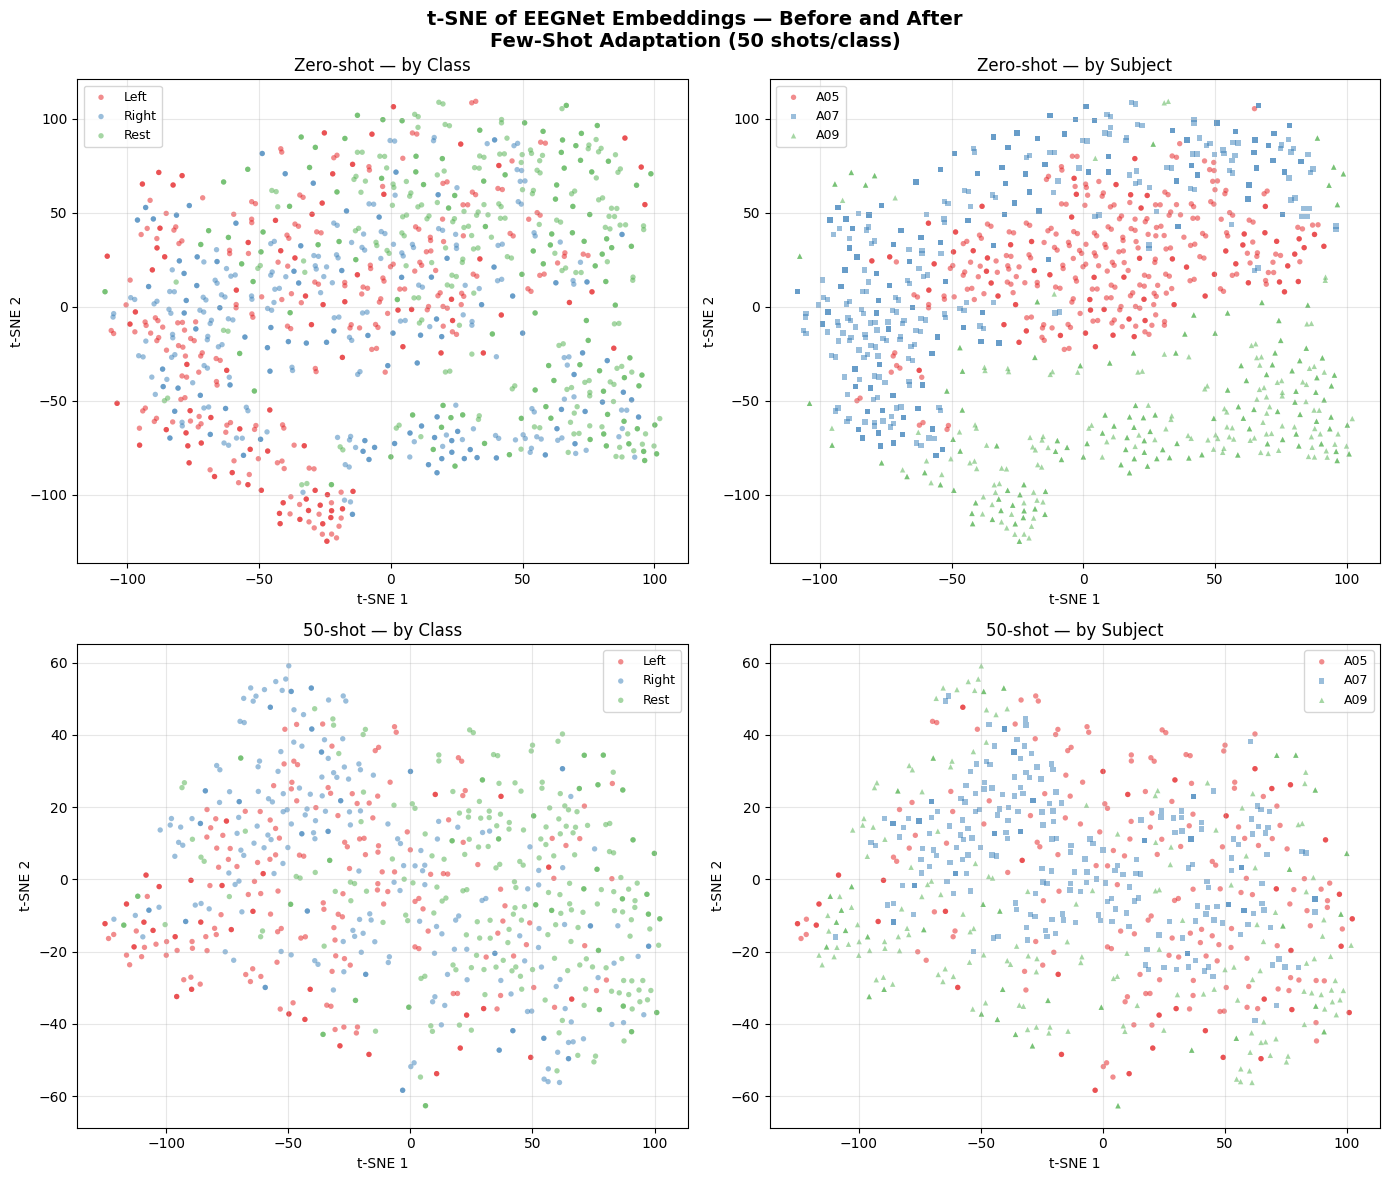

In [15]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.manifold import TSNE
import sys, json
from pathlib import Path

sys.path.insert(0, '.')

from ml_core.models.eegnet import EEGNet
from ml_core.models.shallowconv import ShallowConvNet
from ml_core.data import read_epochs, EpochDataset
from ml_core.data.normalize import EuclideanAligner, NormStats
from torch.utils.data import DataLoader
from torch.optim import AdamW
import torch.nn as nn

device = torch.device("mps" if torch.backends.mps.is_available()
                       else "cpu")
print(f"Device: {device}")

PROJECT_ROOT = Path("/Users/janardhanareddyms/Documents/Tandon/courses/bigdata/projectcerebro")

DELTA_PATH   = str(PROJECT_ROOT / "delta_lake/epochs_mi_v1_ch5_sr128_bp8_30")
FILTER_VER   = "bp_8_30_v1"
EEGNET_CKPT  = str(PROJECT_ROOT / "artifacts/checkpoints/eegnet_physionet_seed42/best.pt")
ALIGNER_PATH  = str(PROJECT_ROOT / "artifacts/checkpoints/eegnet_physionet_seed42/euclidean_aligner.npz")
NORM_PATH     = str(PROJECT_ROOT / "artifacts/checkpoints/eegnet_physionet_seed42/norm_stats.json")
FIGURES_DIR   = PROJECT_ROOT / "artifacts/figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

import sys
sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")
print(f"Delta path exists: {Path(DELTA_PATH).exists()}")
print(f"EEGNet ckpt exists: {Path(EEGNET_CKPT).exists()}")


Path("artifacts/figures").mkdir(parents=True, exist_ok=True)



SUBJECTS     = ["A05", "A07", "A09"]  # hard + easy
SHOTS        = 50
ADAPT_EPOCHS = 20
ADAPT_LR     = 1e-3
SEED         = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

LABEL_NAMES  = {0: "Left", 1: "Right", 2: "Rest"}
CLASS_COLORS = {0: "#e41a1c", 1: "#377eb8", 2: "#4daf4a"}
SUBJ_MARKERS = {"A05": "o", "A07": "s", "A09": "^"}
SUBJ_COLORS  = {"A05": "#e41a1c", "A07": "#377eb8", "A09": "#4daf4a"}

# ── Load data ────────────────────────────────────────
df     = read_epochs(DELTA_PATH, filter_version=FILTER_VER)
bci_df = df[df.subject_id.isin(SUBJECTS)].reset_index(drop=True)
print(f"Total epochs: {len(bci_df)}")

# ── Load normalizers ─────────────────────────────────
aligner = EuclideanAligner.load(ALIGNER_PATH)
with open(NORM_PATH) as f:
    ns = json.load(f)
norm = NormStats(
    mean=np.array(ns["mean"]),
    std=np.array(ns["std"]),
    fitted_on_n_epochs=ns["fitted_on_n_epochs"]
)

# ── Helper: get embeddings from EEGNet ───────────────
def get_embeddings(model, df, aligner, norm, device):
    dataset = EpochDataset(df, aligner=aligner, norm_stats=norm)
    loader  = DataLoader(dataset, batch_size=64, shuffle=False)
    model.eval()
    embs = []
    labs = []

    with torch.no_grad():
        for batch in loader:
            X = batch[0].to(device)
            y = batch[1]
            _, emb = model(X, return_embedding=True)
            embs.append(emb.cpu().numpy())
            labs.append(y.numpy())

    embs = np.concatenate(embs)
    labs = np.concatenate(labs)

    # Subject IDs come directly from df (order preserved)
    subjs = df["subject_id"].values[:len(labs)]

    return embs, labs, subjs

# ── Helper: few-shot adapt classifier only ───────────
def adapt_model(model, subject_df, shots, adapt_epochs,
                adapt_lr, aligner, norm, device, seed):
    np.random.seed(seed)
    torch.manual_seed(seed)

    # Stratified calibration sample
    cal_rows = []
    for label in [0, 1, 2]:
        cls_df = subject_df[subject_df.label_code == label]
        n = min(shots, len(cls_df))
        cal_rows.append(cls_df.sample(n=n, random_state=seed))
    cal_df = pd.concat(cal_rows)

    # Freeze backbone
    for param in model.parameters():
        param.requires_grad = False
    for param in model.classifier.parameters():
        param.requires_grad = True

    cal_dataset = EpochDataset(cal_df, aligner=aligner,
                                norm_stats=norm)
    cal_loader  = DataLoader(cal_dataset, batch_size=16,
                              shuffle=True)

    optimizer = AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=adapt_lr
    )
    criterion = nn.CrossEntropyLoss()

    model.train()
    for epoch in range(adapt_epochs):
        for batch in cal_loader:
            X, y = batch[0].to(device), batch[1].to(device)
            optimizer.zero_grad()
            logits = model(X)
            loss   = criterion(logits, y)
            loss.backward()
            optimizer.step()
    model.eval()
    return model, cal_df.index

import pandas as pd

# ── Collect zero-shot embeddings ─────────────────────
print("\nCollecting zero-shot embeddings...")
eegnet = EEGNet(n_classes=3, n_channels=5, n_samples=512).to(device)
ckpt   = torch.load(EEGNET_CKPT, map_location=device)
eegnet.load_state_dict(ckpt["state_dict"])

zero_embs, zero_labs, zero_subjs = get_embeddings(
    eegnet, bci_df, aligner, norm, device
)
print(f"Zero-shot embeddings: {zero_embs.shape}")

# ── Collect few-shot embeddings ──────────────────────
print("Collecting few-shot embeddings...")
few_embs_list  = []
few_labs_list  = []
few_subjs_list = []

for subj in SUBJECTS:
    subj_df = bci_df[bci_df.subject_id == subj].copy()

    # Fresh model load
    model = EEGNet(n_classes=3, n_channels=5, n_samples=512).to(device)
    ckpt  = torch.load(EEGNET_CKPT, map_location=device)
    model.load_state_dict(ckpt["state_dict"])

    # Adapt to subject
    model, cal_idx = adapt_model(
        model, subj_df, SHOTS, ADAPT_EPOCHS,
        ADAPT_LR, aligner, norm, device, SEED
    )

    # Evaluate on remaining epochs
    eval_df = subj_df.drop(cal_idx)
    embs, labs, subjs = get_embeddings(
        model, eval_df, aligner, norm, device
    )
    few_embs_list.append(embs)
    few_labs_list.append(labs)
    few_subjs_list.append(subjs)
    print(f"  {subj}: {len(eval_df)} eval epochs")

few_embs  = np.concatenate(few_embs_list)
few_labs  = np.concatenate(few_labs_list)
few_subjs = np.concatenate(few_subjs_list)

# ── Run t-SNE on both ────────────────────────────────
print("\nRunning t-SNE...")
tsne = TSNE(n_components=2, random_state=42,
            perplexity=30, n_iter=1000)

zero_2d = tsne.fit_transform(zero_embs)

tsne2    = TSNE(n_components=2, random_state=42,
                perplexity=30, n_iter=1000)
few_2d   = tsne2.fit_transform(few_embs)
print("t-SNE done")

# ── Plot ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle(
    "t-SNE of EEGNet Embeddings — Before and After\n"
    "Few-Shot Adaptation (50 shots/class)",
    fontsize=14, fontweight="bold"
)

# ── Panel 1: Zero-shot by CLASS ──────────────────────
ax = axes[0][0]
for lc, lname in LABEL_NAMES.items():
    mask = zero_labs == lc
    ax.scatter(zero_2d[mask, 0], zero_2d[mask, 1],
               c=CLASS_COLORS[lc], label=lname,
               alpha=0.5, s=15, edgecolors="none")
ax.set_title("Zero-shot — by Class", fontsize=12)
ax.legend(fontsize=9)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.grid(True, alpha=0.3)

# ── Panel 2: Zero-shot by SUBJECT ────────────────────
ax = axes[0][1]
for subj in SUBJECTS:
    mask = zero_subjs == subj
    ax.scatter(zero_2d[mask, 0], zero_2d[mask, 1],
               c=SUBJ_COLORS[subj],
               marker=SUBJ_MARKERS[subj],
               label=subj, alpha=0.5, s=15,
               edgecolors="none")
ax.set_title("Zero-shot — by Subject", fontsize=12)
ax.legend(fontsize=9)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.grid(True, alpha=0.3)

# ── Panel 3: Few-shot by CLASS ────────────────────────
ax = axes[1][0]
for lc, lname in LABEL_NAMES.items():
    mask = few_labs == lc
    ax.scatter(few_2d[mask, 0], few_2d[mask, 1],
               c=CLASS_COLORS[lc], label=lname,
               alpha=0.5, s=15, edgecolors="none")
ax.set_title("50-shot — by Class", fontsize=12)
ax.legend(fontsize=9)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.grid(True, alpha=0.3)

# ── Panel 4: Few-shot by SUBJECT ──────────────────────
ax = axes[1][1]
for subj in SUBJECTS:
    mask = few_subjs == subj
    ax.scatter(few_2d[mask, 0], few_2d[mask, 1],
               c=SUBJ_COLORS[subj],
               marker=SUBJ_MARKERS[subj],
               label=subj, alpha=0.5, s=15,
               edgecolors="none")
ax.set_title("50-shot — by Subject", fontsize=12)
ax.legend(fontsize=9)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(FIGURES_DIR / "tsne_before_after.png"), ...)
plt.show()
print("Saved: artifacts/figures/tsne_before_after.png")